In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor, VotingRegressor

# Import advanced algorithms
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

## 1. Data Collection

In [2]:
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
print(train.head(5))
print(test.head())

   TransactionID  TargetValue  AssetID  ProductConfigID DataOriginCode  \
0        1139309      57000.0   117665               88         ACH138   
1        1139316      26500.0  1001282             4616         ACH138   
2        1139317      21000.0   772709             1948         ACH138   
3        1139322      27000.0   902010             3550         ACH138   
4        1139333      21500.0  1036259            36014         ACH138   

  VendorPartnerID  ManufactureYear  OperationalHoursMeter UtilizationTier  \
0             GTX             1997                 4640.0             Low   
1             GTX             2005                  508.0             Low   
2             GTX             1994                11540.0            High   
3             GTX             2002                 4883.0            High   
4             GTX             2009                  302.0             Low   

  TransactionDate  ...   col20                col21                col22  \
0      2005-03-2

In [3]:
if 'TransactionDate' in train.columns:
    train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
    train = train.sort_values('TransactionDate').reset_index(drop=True)

## 2. Exploratory Data Analysis (EDA)

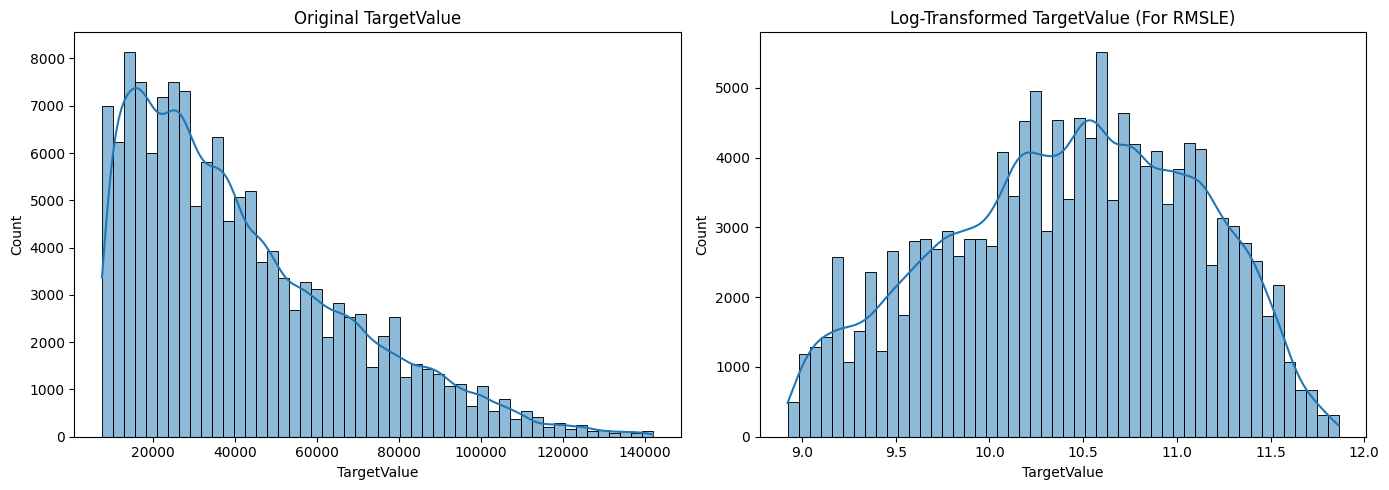

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['TargetValue'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Original TargetValue')

sns.histplot(np.log1p(train['TargetValue']), bins=50, kde=True, ax=ax[1])
ax[1].set_title('Log-Transformed TargetValue (For RMSLE)')
plt.tight_layout()

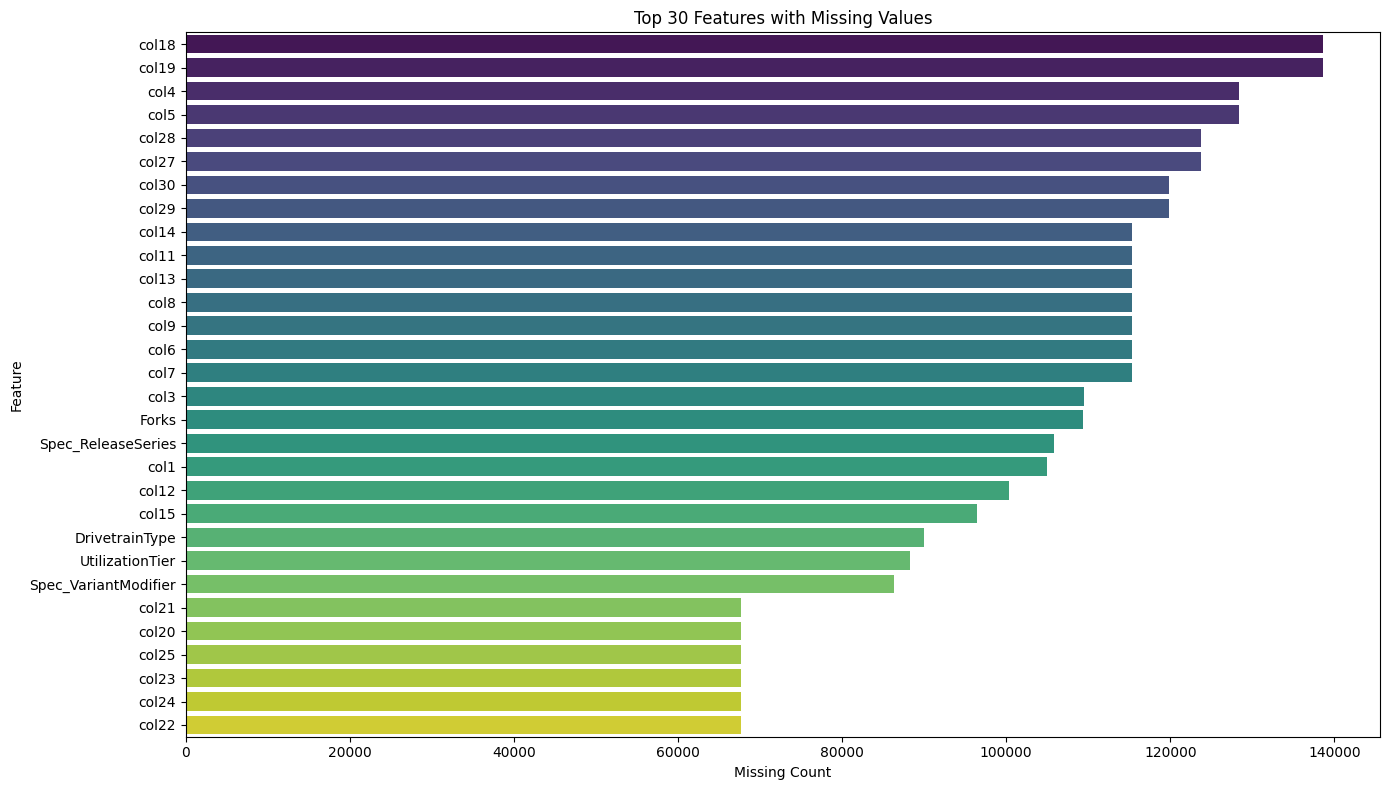

In [5]:
## Missing Values Analysis
plt.figure(figsize=(14, 8))
# Calculate missing values
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
# Plot top 30 missing value columns to keep it legible
sns.barplot(x=missing.values[:30], y=missing.index[:30], palette="viridis")
plt.title('Top 30 Features with Missing Values')
plt.xlabel('Missing Count')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

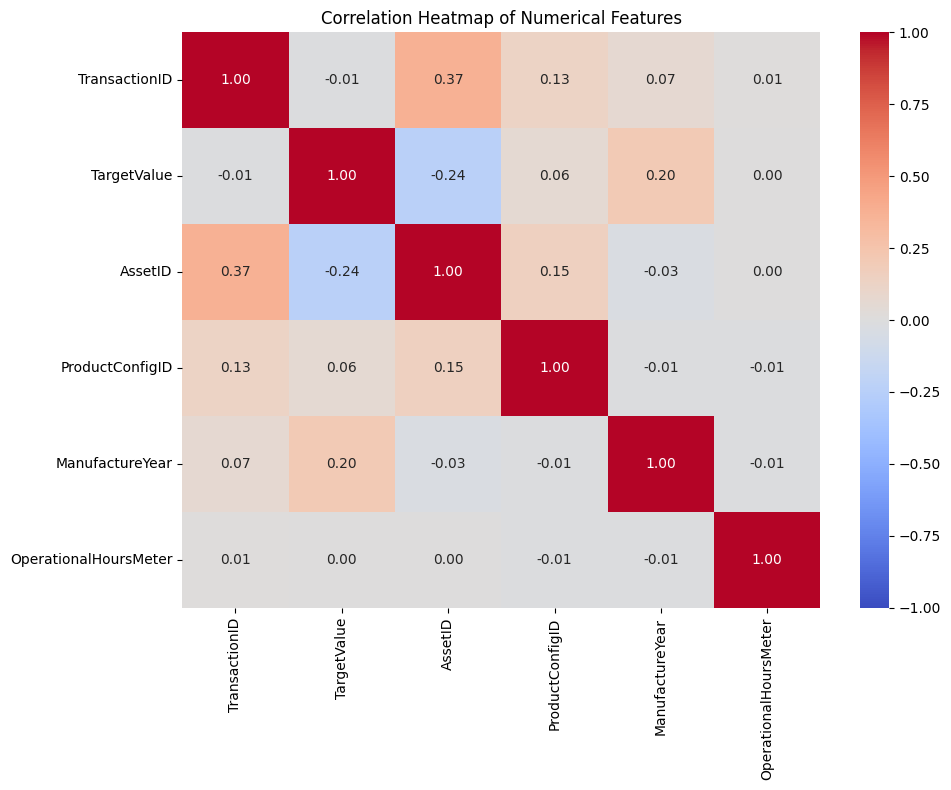

In [6]:
#  Correlation Matrix of Numerical Features
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

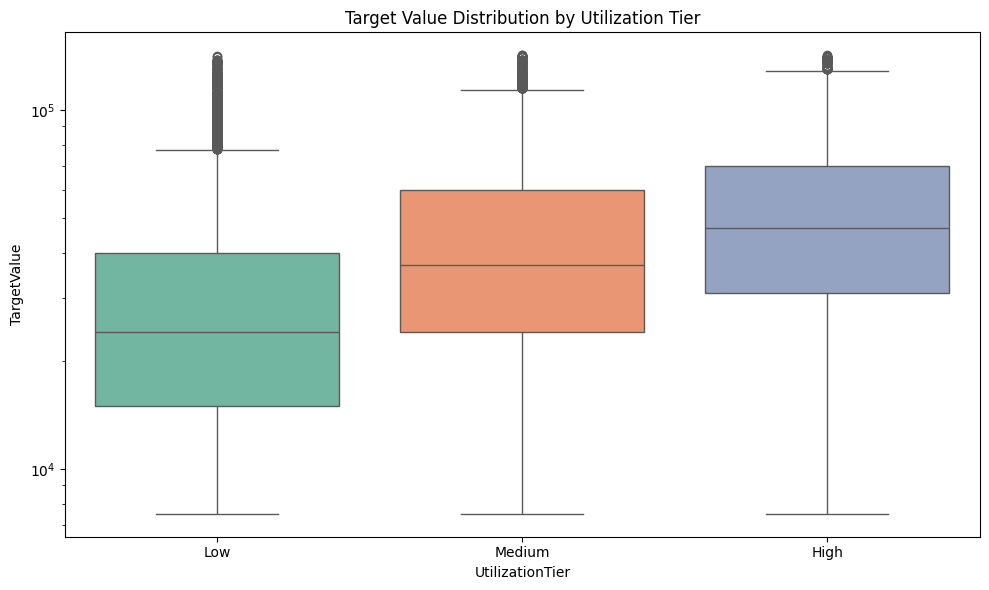

In [7]:
#  Target Value Distribution by Utilization Tier (Categorical Analysis)
# We use a log scale here because the TargetValue has extreme outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='UtilizationTier', y='TargetValue', palette='Set2')
plt.title('Target Value Distribution by Utilization Tier')
plt.yscale('log') 
plt.tight_layout()
plt.show()

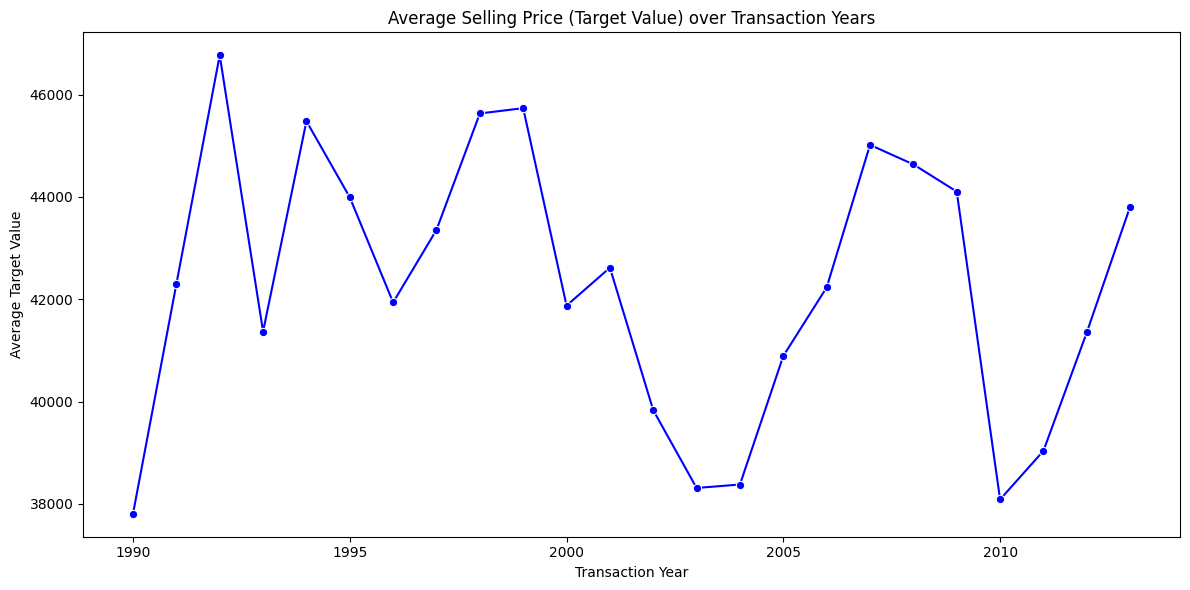

In [8]:
#  Target Value Over Time (Market Trend Analysis)
plt.figure(figsize=(12, 6))
# Extract year from TransactionDate for grouping
train['TransactionYear'] = train['TransactionDate'].dt.year
yearly_avg = train.groupby('TransactionYear')['TargetValue'].mean().reset_index()
sns.lineplot(data=yearly_avg, x='TransactionYear', y='TargetValue', marker='o', color='b')
plt.title('Average Selling Price (Target Value) over Transaction Years')
plt.xlabel('Transaction Year')
plt.ylabel('Average Target Value')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [5]:
def preprocess_data(df):
    df = df.copy()
    
    # Extract robust time features
    if 'TransactionDate' in df.columns:
        df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
        
        df['SaleYear'] = df['TransactionDate'].dt.year
        df['SaleMonth'] = df['TransactionDate'].dt.month
        df['SaleDayOfYear'] = df['TransactionDate'].dt.dayofyear
        df['SaleWeekOfYear'] = df['TransactionDate'].dt.isocalendar().week.astype(int)
        
        # Crucial depreciation feature
        if 'ManufactureYear' in df.columns:
            df['EquipmentAge'] = df['SaleYear'] - df['ManufactureYear']
            df['EquipmentAge'] = df['EquipmentAge'].apply(lambda x: x if x > 0 else 0)
            
        df = df.drop(columns=['TransactionDate'])

    # Force IDs to be strings so TargetEncoder can calculate their historical prices
    id_cols = ['AssetID', 'ProductConfigID']
    for col in id_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)
            
    # Fill NAs in string categories
    cat_cols = df.select_dtypes(include=['object']).columns
    df[cat_cols] = df[cat_cols].fillna("missing_value")
    
    return df

print("3. Preprocessing data...")
train_clean = preprocess_data(train)
test_clean = preprocess_data(test)

3. Preprocessing data...


## 4. Select Dependent (y) and Independent (X) Features

In [6]:
target_col = 'TargetValue'
features = [col for col in train_clean.columns if col not in ['TransactionID', target_col]]

X = train_clean[features]
test_clean = test_clean[features]

# Log transform for Kaggle's RMSLE metric
y = np.log1p(train_clean[target_col])

## 5. LABEL ENCODING & FEATURE TRANSFORMATION (PIPELINE)

In [7]:
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32']).columns
cat_cols = X.select_dtypes(include=['object']).columns

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('target_enc', TargetEncoder(target_type='continuous', smooth="auto"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

## 6. Split Data into Train and Test (Validation) Data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## 7. Select and Evaluate 3 Appropriate ML Models

In [9]:
models = {
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, random_state=42, n_jobs=-1, verbose=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=150, random_state=42)
}

best_model_name = ""
best_model_pipeline = None
best_score = float('inf')

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    rmsle = np.sqrt(mean_squared_error(y_test, preds))
    print(f"   -> {name} Validation RMSLE: {rmsle:.4f}")
    
    if rmsle < best_score:
        best_score = rmsle
        best_model_pipeline = pipeline
        best_model_name = name

print(f"\n   WINNER: {best_model_name} selected for hyperparameter tuning.")

   -> LightGBM Validation RMSLE: 0.2658
   -> XGBoost Validation RMSLE: 0.2620
   -> HistGradientBoosting Validation RMSLE: 0.2691

   WINNER: XGBoost selected for hyperparameter tuning.


## 8. Hyperparameter Tuning (on the best model)

In [10]:
if best_model_name == 'LightGBM':
    param_grid = {
        'model__n_estimators': [800, 1000],
        'model__learning_rate': [0.03, 0.05],
        'model__num_leaves': [63, 127]
    }
elif best_model_name == 'XGBoost':
    param_grid = {
        'model__n_estimators': [800, 1000],
        'model__learning_rate': [0.03, 0.05],
        'model__max_depth': [8, 10]
    }
else:
    param_grid = {
        'model__max_iter': [800, 1000],
        'model__learning_rate': [0.03, 0.05]
    }

search = RandomizedSearchCV(
    best_model_pipeline, 
    param_distributions=param_grid, 
    n_iter=3, 
    cv=3, 
    scoring='neg_mean_squared_error', 
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(f"   Best parameters found: {search.best_params_}")

   Best parameters found: {'model__n_estimators': 800, 'model__max_depth': 8, 'model__learning_rate': 0.03}


## 9. TRAIN FINAL ENSEMBLE & GENERATE PREDICTIONS

In [11]:
best_params = search.best_params_
opt_trees = best_params.get('model__n_estimators', best_params.get('model__max_iter', 1000))
opt_lr = best_params['model__learning_rate']

xgb_final = xgb.XGBRegressor(
    n_estimators=opt_trees, 
    max_depth=10, 
    learning_rate=opt_lr, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1
)

lgb_final = lgb.LGBMRegressor(
    n_estimators=opt_trees, 
    num_leaves=127, 
    learning_rate=opt_lr, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1, 
    verbose=-1
)

hist_final = HistGradientBoostingRegressor(
    max_iter=opt_trees, 
    learning_rate=opt_lr, 
    random_state=42
)

# 3-Model Voting Regressor with optimal weighting for best score
ensemble = VotingRegressor(
    estimators=[('xgb', xgb_final), ('lgb', lgb_final), ('hist', hist_final)],
    weights=[0.70, 0.20, 0.10] 
)

tuned_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', ensemble)])

print("   Fitting final models...")
tuned_pipeline.fit(X, y)

print("   Generating predictions...")
log_predictions = tuned_pipeline.predict(test_clean)

# Reverse log transform to get dollar values
final_predictions = np.expm1(log_predictions)

   Fitting final models...
   Generating predictions...


## 10. GENERATE SUBMISSION.CSV

In [12]:
submission = pd.DataFrame({
    'TransactionID': test['TransactionID'], # This is now perfectly aligned with the predictions!
    'TargetValue': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Pipeline complete! 'submission.csv' generated")

Pipeline complete! 'submission.csv' generated
